# **Airline Passenger Satisfaction Analysis & Prediction**

## **1. Introduction**
---

Kepuasan penumpang menjadi salah satu aspek yang dapat digunakan untuk melihat bagaimana kualitas pelayanan sebuah maskapai penerbangan. Oleh karena itu, diperlukan analisis untuk memahami faktor-faktor yang berkaitan dengan kepuasan maupun ketidakpuasan penumpang terhadap layanan yang diberikan.

Proyek ini tidak hanya berfokus pada **identifikasi faktor yang berkaitan dengan kepuasan penumpang**, tetapi juga mencoba membangun model untuk **memprediksi kepuasan penumpang** berdasarkan berbagai karakteristik perjalanan dan pengalaman layanan.

Dalam proyek ini, akan dilakukan analisis dan prediksi Kepuasan Layanan Maskapai Penerbangan dengan `satisfaction` sebagai kolom target dan kolom lainnya sebagai prediktor dengan menerapkan beberapa tahapan analisis data, mulai dari **Exploratory Data Analysis (EDA), data preprocessing, pembangunan dan evaluasi model prediksi dengan Logistic Regression**, hingga menghasilkan beberapa insight berdasarkan hasil analisis.

## **2. Data Preparation**
---
Dataset yang digunakan dalam proyek analisis ini adalah data *"Airline Satisfaction Data*" yang tersedia di Kaggle (https://www.kaggle.com/datasets/arseniyshutko/binary-aviation-satisfaction-129k). Dataset ini terdiri dari 129.000+ record (baris) dan 22 atributes (kolom) yang berisi informasi mengenai pengalaman penumpang maskapai.

Berikut ini adalah penjelasan 22 kolom pada dataset.
| No | Nama Kolom     | Deskripsi                                |
|--- | -------------- | ---------------------------------------- |
|  1 |`Gender`     | Gender penumpang (Female/Male)|
|  2 |`Customer Type`  | Tipe penumpang (Loyal/Disloyal)|
|  3 |`Age` | Usia penumpang|
|  4 |`Type of Travel` | Tujuan perjalanan (Personal/Business)|
|  5 |`Class`    | Kelas penerbangan (Business/Eco/Eco Plus)|
|  6 |`Flight Distance`|Jarak penerbangan (Km)|
|  7 |`Inflight wifi service`| Rating kepuasan WiFi (1-5)|
|  8 | `Departure/Arrival time convenient`| Rating kepuasan waktu keberangkatan/kedatangan (1-5)|
|  9 | `Ease of Online booking` | Rating kepuasan proses booking online (1-5)|
|  10| `Gate location` | Rating kepuasan lokasi pintu masuk (1-5)|
|  11| `Food and drink`     | Rating kepuasan makanan & minuman (1-5)|
|  12| `Online Boarding`   | Rating kepuasan check-in online (1-5)|
|  13| `Seat comfort`        | Rating kepuasan kenyamanan kursi (1-5)|
|  14| `Inflight entertainment`  | Rating kepuasan opsi hiburan (1-5)|
|  15| `On-board service`     | Rating kepuasan layanan dalam pesawat (1-5)|
|  16|`Leg room service`  | Rating kepuasan ruang kaki (1-5)|
|  17| `Baggage handling` | Rating kepuasan penanganan bagasi (1-5)|
|  18|`Checkin service`      | Rating kepuasan layanan check-in (1-5)|
|  19|`Cleanliness`    | Rating kepuasan atas kebersihan kabin (1-5)|
|  20|`Departure Delay in Minutes`  | Waktu penundaan keberangkatan (menit)|
|  21| `Arrival Delay in Minutes`| Waktu penundaan kedatangan (menit)|
|  22| `satisfaction`| Kepuasan pelanggan (True = pelanggan puas, False = pelanggan tidak puas)|




**2.1 Import Library dan Packages yang diperlukan**

* **`Pandas`**: Manipulasi data, pembersihan data, dan analisis data.
* **`NumPy`**: Melakukan operasi numerik dan pengolahan data.
* **`Matplotlib`**: Membuat visualisasi dan grafik data.
* **`Seaborn`**: Membuat visualisasi statistik dengan tampilan yang lebih informatif dan menarik.
* **`Scikit-learn`**: Mendukung proses preprocessing, pembagian dataset, pembangunan model machine learning, dan evaluasi model.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

sns.set_style("whitegrid")
%matplotlib inline

**2.2 Menghubungkan dengan Folder Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir()

Mounted at /content/drive


['.config', 'drive', 'sample_data']

**2.3 Import Dataset**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Dataset Projek/flight_dataset.csv", header = 0)
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,5,4,3,4,4,5,25,18.0,False
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,1,5,3,1,1,1,6.0,False
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,5,4,3,4,4,5,0,0.0,True
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,2,5,3,1,2,11,9.0,False
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,5,3,3,4,4,3,3,0,0.0,True


## **3. Exploratory Data Analysis (EDA)**
---
Exploratory Data Analysis (EDA) merupakan analisis awal yang dilakukan untuk mengetahui dan memahami karakteristik, pola, hingga distribusi dari suatu dataset sebelum melakukan analisis lanjutan.

### **1. Informasi Dataset**

**Jumlah Kolom dan Baris dari Dataset**

In [ ]:
# Menampilkan ukuran dataset
print (f"Jumlah Kolom: {df.shape[1]}")
print (f"Jumlah Baris: {df.shape[0]}")

Jumlah Kolom: 22
Jumlah Baris: 129880


**Tipe Dataset**

In [ ]:
df.dtypes

,0
Gender,object
Customer Type,object
Age,int64
Type of Travel,object
Class,object
Flight Distance,int64
Inflight wifi service,int64
Departure/Arrival time convenient,int64
Ease of Online booking,int64
Gate location,int64


In [ ]:
# Menghitung jumlah masing-masing tipe data
categoric_cols = df.select_dtypes(include=['object', 'category']).columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
bool_cols = df.select_dtypes(include=['bool']).columns

print(f"""Dataset memiliki {len(categoric_cols)} atribut tipe kategorik (Gender, Customer type, Type of Travel, Class),
{len(bool_cols)} atribut biner (boolean) yaitu satisfaction, dan sisanya {len(numeric_cols)} atribut numerik""")

Dataset memiliki 4 atribut tipe kategorik (Gender, Customer type, Type of Travel, Class),
1 atribut biner (boolean) yaitu satisfaction, dan sisanya 17 atribut numerik


### **2. Statistik Deskriptif**
Statistik Deskriptif digunakan untuk mengetahui gambaran umum dan karakteristik kolom numerik meliputi **jumlah data, rataan, standar deviasi, nilai minimum dan maksimum, hingga persen kuartil** dari dataset.

In [ ]:
df.describe()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.286326,14.713713,15.091129
std,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.313682,38.071126,38.465650
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,3.000000,0.000000,0.000000
75%,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


**Nama Unik Setiap Variabel Kategorikal**

In [ ]:
cols = ['Customer Type', 'Class', 'Type of Travel']
for col in cols:
    print(f"{col}:")
    print(f"Jumlah nilai unik: {df[col].nunique()}")
    print(f"Nilai unik: {df[col].unique()}")
    print()

Customer Type:
Jumlah nilai unik: 2
Nilai unik: ['Loyal Customer' 'disloyal Customer']

Class:
Jumlah nilai unik: 3
Nilai unik: ['Eco Plus' 'Business' 'Eco']

Type of Travel:
Jumlah nilai unik: 2
Nilai unik: ['Personal Travel' 'Business travel']



### **3. Indentifikasi Missing Value**

In [ ]:
mis_value = df.isnull().sum()
print(f'Kolom yang Terdapat Missing Value:\n')
mis_value[df.isnull().sum()>0]

Kolom yang Terdapat Missing Value:



,0
Arrival Delay in Minutes,393


Output menunjukkan bahwa terdapat **393 nilai yang hilang** dari kolom `Arrival Delay in Minutes`, sehingga perlu dilakukan penanganan sebelum melakukan analisis dan pemodelan lebih lanjut untuk mempertahankan kekonsistenan dan keakuratan hasil analisis.

### **4. Distribusi & Proporsi Kolom Target (`satisfaction`)**


In [ ]:
print ('Proporsi Kolom Target (dalam %):')
df['satisfaction'].value_counts(normalize=True)*100

Proporsi Kolom Target (dalam %):


,proportion
satisfaction,
False,56.553742
True,43.446258


In [ ]:
print("Jumlah Penumpang yang Puas:", (df['satisfaction'] == True).sum())
print("Jumlah Penumpang yang Tidak Puas:", (df['satisfaction'] == False).sum())

Jumlah Penumpang yang Puas: 56428
Jumlah Penumpang yang Tidak Puas: 73452


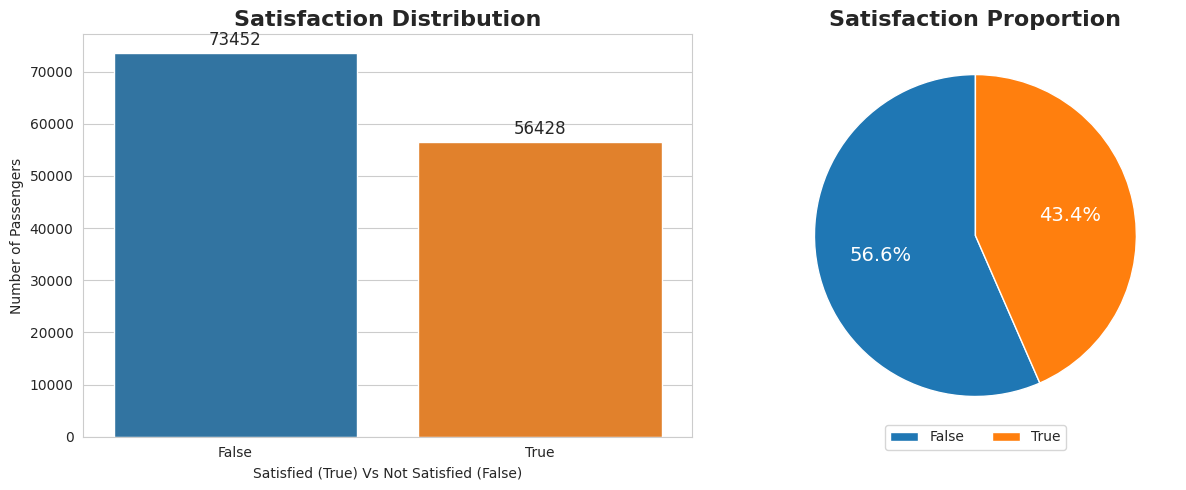

In [ ]:
counts = df["satisfaction"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Column Chart
ax = sns.countplot(data=df, x="satisfaction", hue="satisfaction",
    legend=False, ax=axes[0])

axes[0].set_title("Satisfaction Distribution", fontsize=16, fontweight="bold")

axes[0].set_xlabel("Satisfied (True) Vs Not Satisfied (False)")
axes[0].set_ylabel("Number of Passengers")

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3)

# Pie Chart
axes[1].pie(counts, autopct="%1.1f%%", startangle=90,
    textprops={"color": "white", "fontsize": 14},
    wedgeprops={"edgecolor": "white", "linewidth": 1})

axes[1].set_title("Satisfaction Proportion", fontsize=16, fontweight="bold")

axes[1].legend(counts.index, loc="lower center",
    bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.tight_layout()
plt.show()

Output menunjukkan bahwa **56,6% atau lebih dari setengah proporsi** pelanggan yang pernah menggunakan layanan maskapai penerbangan merasa tidak puas atas layanan yang diberikan oleh pihak maskapai. Oleh karena itu, perlu dilakukan beberapa evaluasi terhadap aspek-aspek yang memengaruhi kepuasan penumpang untuk meningkatkan kualitas layanan yang diberikan.

### **5. Distribusi & Proporsi Variabel Prediktor**

**5.1 Distribusi dan Proporsi Kolom `Gender`**

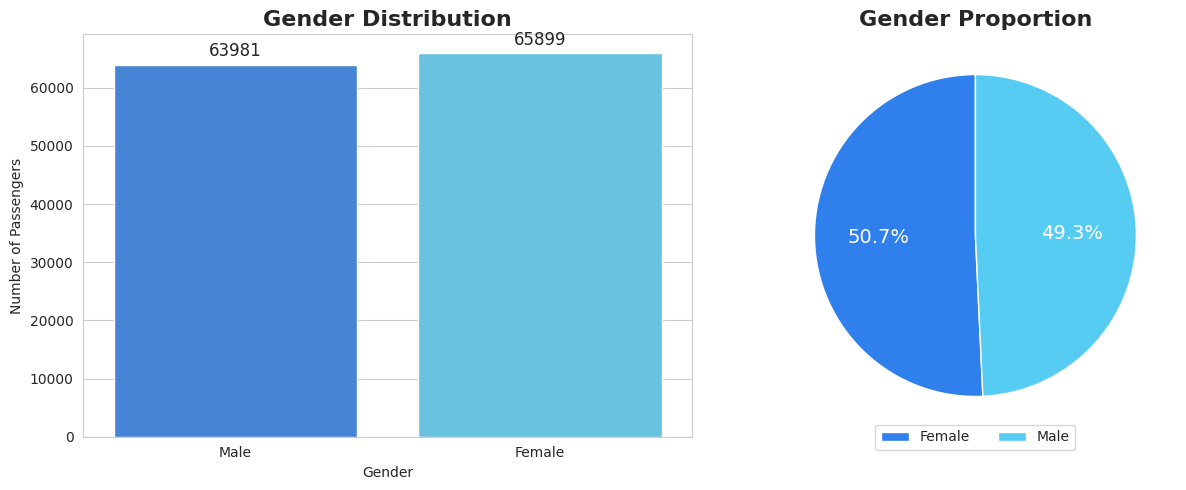

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df["Gender"].value_counts()

# Column Chart
ax = sns.countplot(data=df, x="Gender", hue="Gender", palette=["#2F80ED", "#56CCF2"],
    legend=False, ax=axes[0])

axes[0].set_title("Gender Distribution", fontsize=16, fontweight="bold")

axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Number of Passengers")

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3)

# Pie Chart
axes[1].pie(counts, autopct="%1.1f%%", startangle=90, colors=["#2F80ED", "#56CCF2"],
    textprops={"color": "white", "fontsize": 14},
    wedgeprops={"edgecolor": "white", "linewidth": 1})

axes[1].set_title("Gender Proportion", fontsize=16, fontweight="bold")

axes[1].legend(counts.index, loc="lower center",
    bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.tight_layout()
plt.show()

Hasil visualisasi menunjukkan bahwa proporsi penumpang laki-laki dan perempuan relatif seimbang.

**5.2 Distribusi dan Proporsi Kolom `Customer Type`**

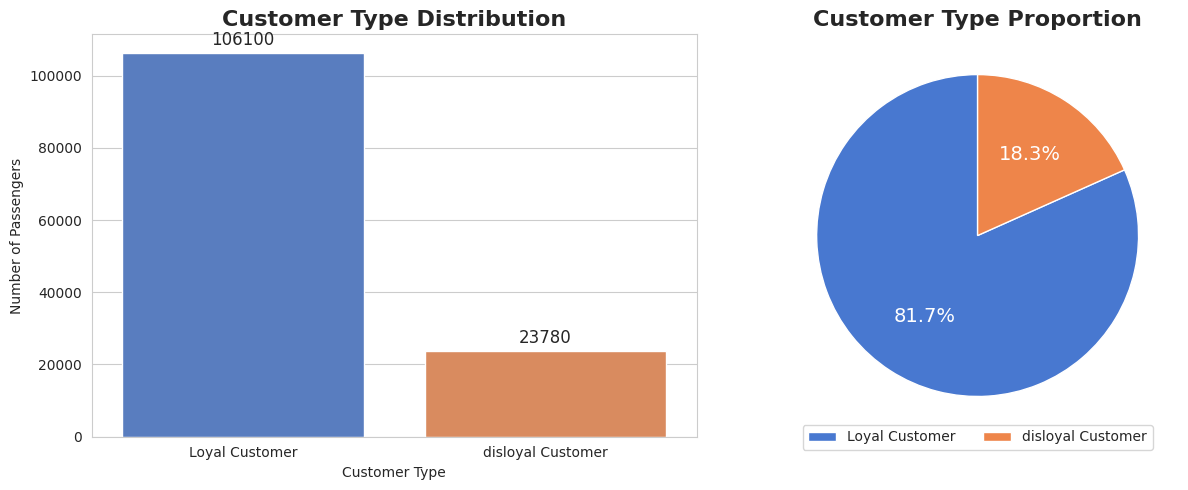

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df["Customer Type"].value_counts()

# Column Chart
ax = sns.countplot(data=df, x="Customer Type", hue="Customer Type", palette='muted',
    legend=False, ax=axes[0])

axes[0].set_title("Customer Type Distribution", fontsize=16, fontweight="bold")

axes[0].set_xlabel("Customer Type")
axes[0].set_ylabel("Number of Passengers")

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3)

# Pie Chart
axes[1].pie(counts, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("muted", n_colors=len(counts)),
    textprops={"color": "white", "fontsize": 14},
    wedgeprops={"edgecolor": "white", "linewidth": 1})

axes[1].set_title("Customer Type Proportion", fontsize=16, fontweight="bold")

axes[1].legend(counts.index, loc="lower center",
    bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.tight_layout()
plt.show()

Hasil menunjukkan bahwa sebagian besar penumpang dalam dataset termasuk ke dalam kategori Loyal Customer, sedangkan **18,3% termasuk ke dalam kategori Disloyal Customer**.

**5.3 Distribusi dan Proporsi Kolom `Type of Travel`**

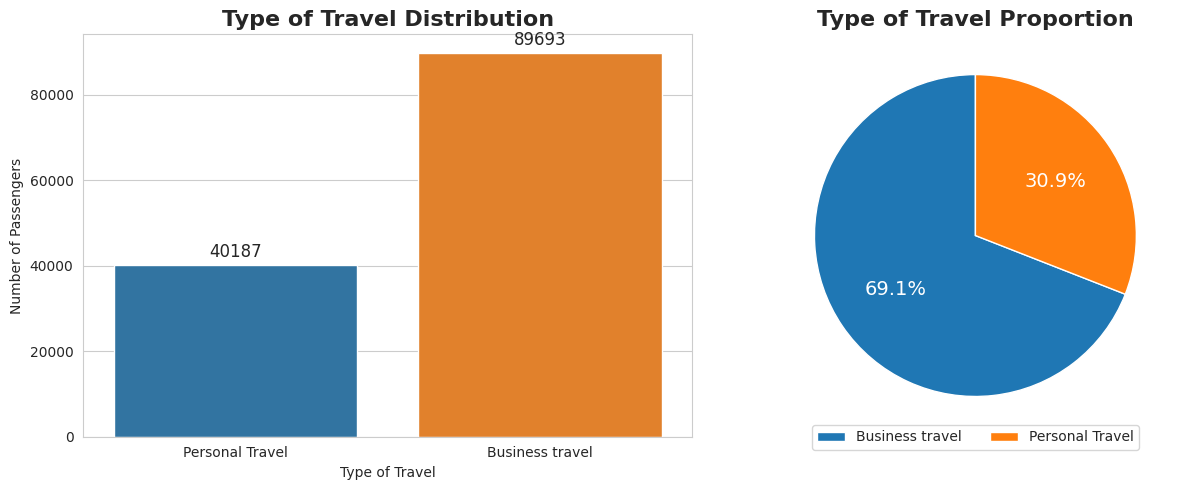

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df["Type of Travel"].value_counts()

# Column Chart
ax = sns.countplot(data=df, x="Type of Travel", hue="Type of Travel",
    legend=False, ax=axes[0])

axes[0].set_title("Type of Travel Distribution", fontsize=16, fontweight="bold")

axes[0].set_xlabel("Type of Travel")
axes[0].set_ylabel("Number of Passengers")

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3)

# Pie Chart
axes[1].pie(counts, autopct="%1.1f%%", startangle=90,
    textprops={"color": "white", "fontsize": 14},
    wedgeprops={"edgecolor": "white", "linewidth": 1})

axes[1].set_title("Type of Travel Proportion", fontsize=16, fontweight="bold")

axes[1].legend(counts.index, loc="lower center",
    bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.tight_layout()
plt.show()

Hasil visualisasi menunjukkan bahwa mayoritas penumpang menggunakan layanan maskapai penerbangan untuk **melakukan perjalanan bisnis (Bisnis Travel)**, sedangkan hanya sebagian penumpang menggunakan layanan tersebut untuk perjalanan pribadi (Personal Travel).

**5.4 Distribusi dan Proporsi Kolom `Class`**

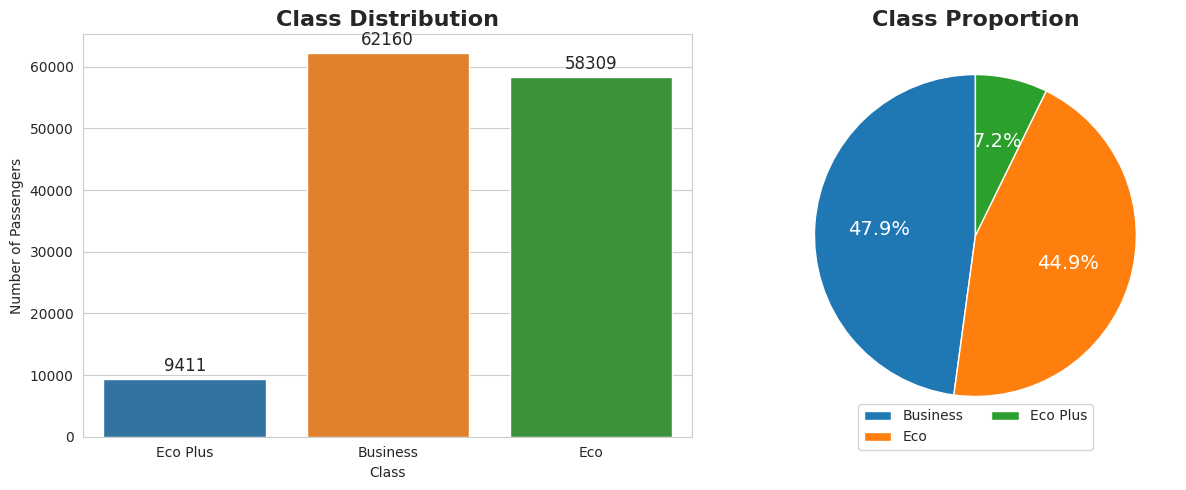

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df["Class"].value_counts()

# Column Chart
ax = sns.countplot(data=df, x="Class", hue="Class",
    legend=False, ax=axes[0])

axes[0].set_title("Class Distribution", fontsize=16, fontweight="bold")

axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Passengers")

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3)

# Pie Chart
axes[1].pie(counts, autopct="%1.1f%%", startangle=90,
    textprops={"color": "white", "fontsize": 14},
    wedgeprops={"edgecolor": "white", "linewidth": 1})

axes[1].set_title("Class Proportion", fontsize=16, fontweight="bold")

axes[1].legend(counts.index, loc="lower center",
    bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.tight_layout()
plt.show()

Hasil visualisasi menunjukkan bahwa sebagian besar penumpang dalam dataset menggunakan **kelas Business dan Eco**. Sebaliknya, kelas Eco Plus memiliki proporsi penumpang yang relatif kecil, yaitu sebesar **7,2% atau sebanyak 9.411 penumpang.**

**5.5 Distribusi Kolom `Age`**

In [ ]:
# Membuat kolom baru kelompok umur yang diberi nama 'age_group'
bins = [0, 18, 30, 45, 60, 100]
labels = ['<18', '18-30', '31-45', '46-60', '>60']

df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)
df['age_group'].value_counts().sort_index()

,count
age_group,
<18,11070
18-30,29810
31-45,41482
46-60,37464
>60,10054


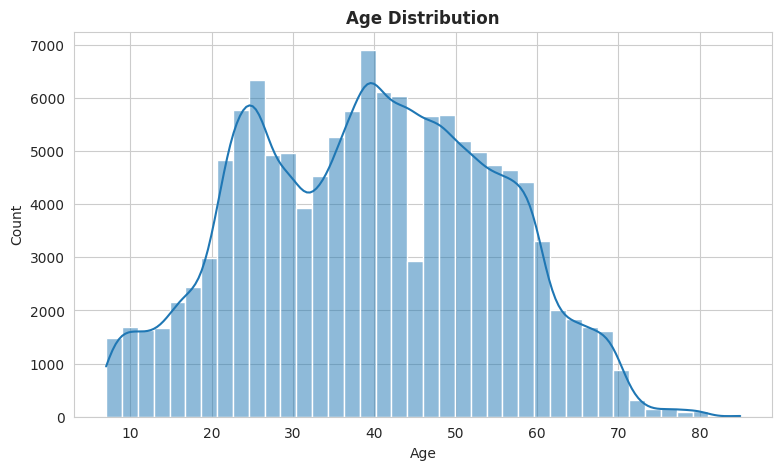

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(data=df, x='Age', bins=40, kde=True)

plt.title('Age Distribution', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**5.6 Distribusi Kolom `Flight Distance`**

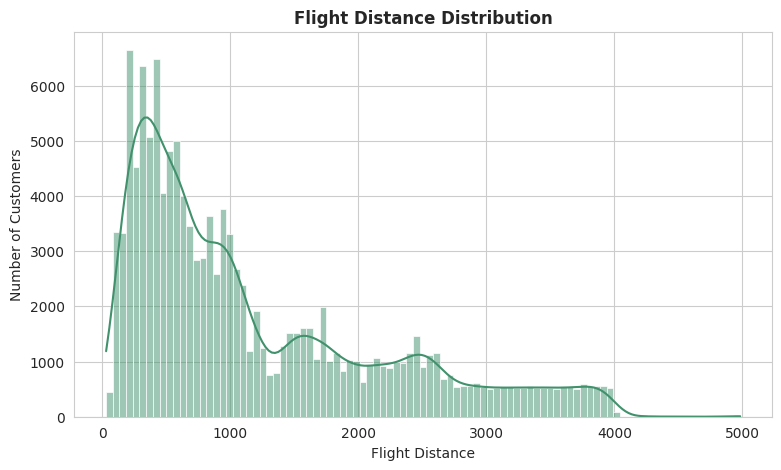

In [ ]:
plt.figure(figsize=(9,5))

sns.histplot(data=df, x='Flight Distance', kde=True, color = "#40916C")

plt.title('Flight Distance Distribution', fontweight='bold')
plt.xlabel('Flight Distance')
plt.ylabel('Number of Customers')
plt.show()

**5.7 Distribusi Kolom `Departure Delay in Minutes`**

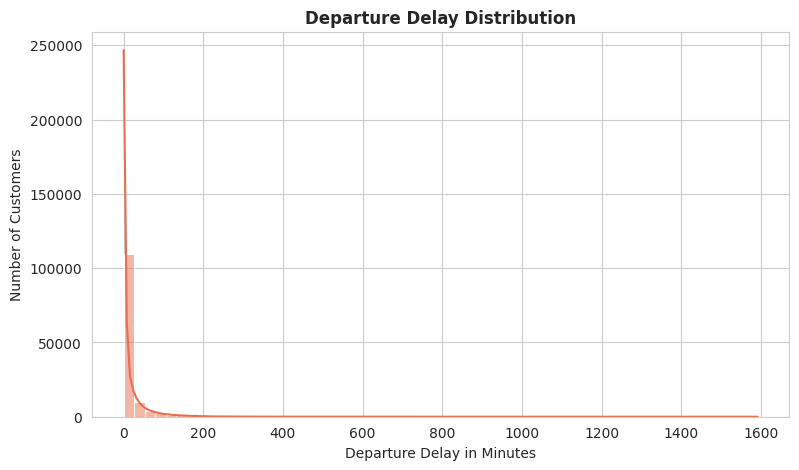

In [ ]:
plt.figure(figsize=(9,5))

sns.histplot(data=df, x='Departure Delay in Minutes', bins = 60, kde=True, color='#E76F51')

plt.title('Departure Delay Distribution', fontweight='bold')
plt.xlabel('Departure Delay in Minutes')
plt.ylabel('Number of Customers')
plt.show()

**5.8 Distribusi Kolom `Arrival Delay in Minutes`**

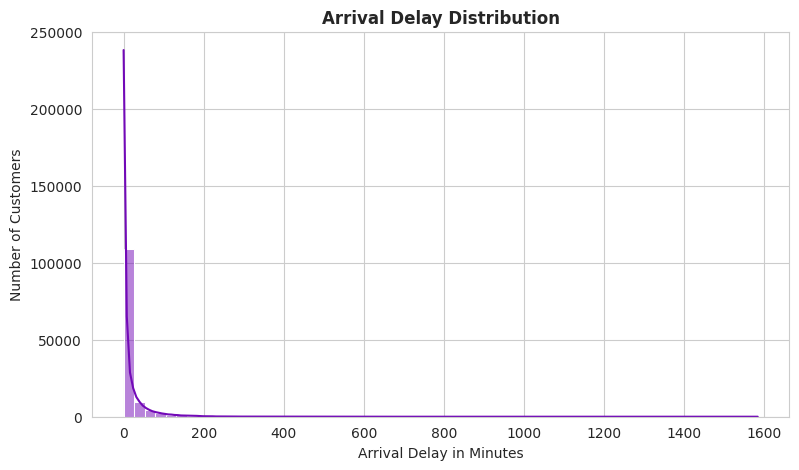

In [ ]:
plt.figure(figsize=(9,5))

sns.histplot(data=df, x='Arrival Delay in Minutes', bins = 60, kde=True, color = '#7209B7')

plt.title('Arrival Delay Distribution', fontweight='bold')
plt.xlabel('Arrival Delay in Minutes')
plt.ylabel('Number of Customers')
plt.show()

**5.9 Proporsi Kepuasan Penumpang Berdasarkan Variabel Kategorik**

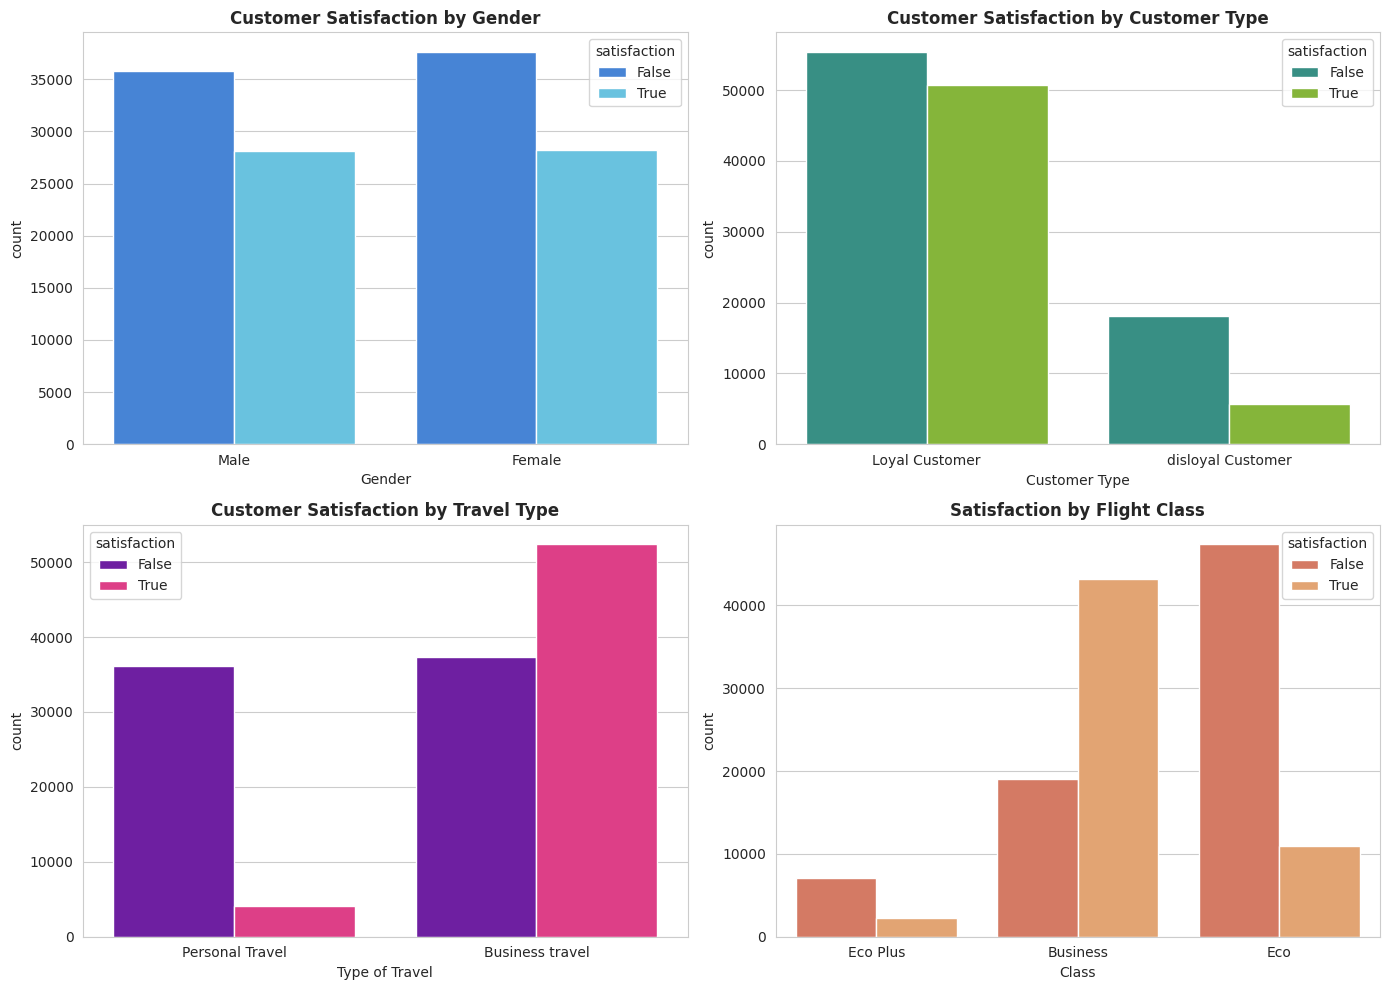

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
colors = [
    ["#2F80ED", "#56CCF2"],
    ["#2A9D8F", "#8AC926"],
    ["#7209B7", "#F72585"],
    ["#E76F51", "#F4A261"]
]

sns.countplot(x='Gender', hue='satisfaction', data=df, ax=axes[0,0], palette = colors[0])
axes[0,0].set_title("Customer Satisfaction by Gender",fontweight='bold')

sns.countplot(x='Customer Type', hue='satisfaction',data=df, ax=axes[0,1], palette = colors[1])
axes[0,1].set_title("Customer Satisfaction by Customer Type",fontweight='bold')

sns.countplot(x='Type of Travel', hue='satisfaction', data=df, ax=axes[1,0], palette = colors[2])
axes[1,0].set_title("Customer Satisfaction by Travel Type",fontweight='bold')

sns.countplot(x='Class', hue='satisfaction',data=df,ax=axes[1,1], palette = colors[3])
axes[1,1].set_title("Satisfaction by Flight Class",fontweight='bold')
plt.tight_layout()
plt.show()

Visualisasi di atas menunjukkan proporsi kepuasan penumpang berdasarkan empat variabel kategori, yaitu `Gender`, `Customer Type`, `Type of Travel`, dan `Class`. Secara umum, sebagian besar kategori menunjukkan **proporsi penumpang yang tidak puas lebih tinggi dibandingkan penumpang yang puas**. Namun, terdapat perbedaan pada kategori **"Business Travel" pada variabel `Type of Travel` dan kategori "Business" pada variabel `Class`**, di mana jumlah penumpang yang merasa puas lebih tinggi dibandingkan dengan penumpang yang merasa tidak puas.

**5.10 Proporsi Kepuasan Penumpang Berdasarkan Usia**

In [ ]:
# Proporsi Kepuasan Berdasarkan Kelompok Usia
age_stsf = pd.crosstab(df['age_group'], df['satisfaction'], normalize='index') * 100
print (f'Dibawah ini adalah Tingkat Kepuasan Berdasarkan Umur Penumpang (dalam %).')
age_stsf

Dibawah ini adalah Tingkat Kepuasan Berdasarkan Umur Penumpang (dalam %).


satisfaction,False,True
age_group,,
<18,82.384824,17.615176
18-30,64.360953,35.639047
31-45,51.193289,48.806711
46-60,42.571535,57.428465
>60,79.182415,20.817585


In [ ]:
# Distribusi Jumlah Penumpang Berdasarkan Kelompok Usia
df['age_group'].value_counts()

,count
age_group,
31-45,41482
46-60,37464
18-30,29810
<18,11070
>60,10054


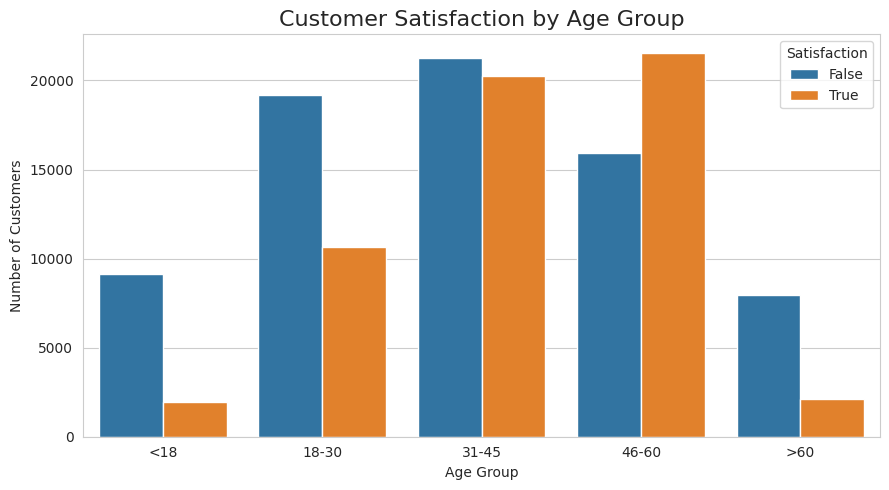

In [ ]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="age_group", hue="satisfaction")
plt.title("Customer Satisfaction by Age Group", fontsize=16)
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()

Visualisasi diatas menunjukkan bahwa kelompok usia **46-60 tahun merupakan satu-satunya kelompok yang didominasi oleh penumpang yang merasa puas** terhadap layanan yang diberikan oleh maskapai, sedangkan kelompok usia lainnya, mayoritas merasa tidak puas. Selain itu, jumlah penumpang terbanyak berasal dari kelompok usia **31-45 tahun, yaitu sebanyak 41.482 orang.**

**5.11 Rating Rata-rata Pelayanan Maskapai**

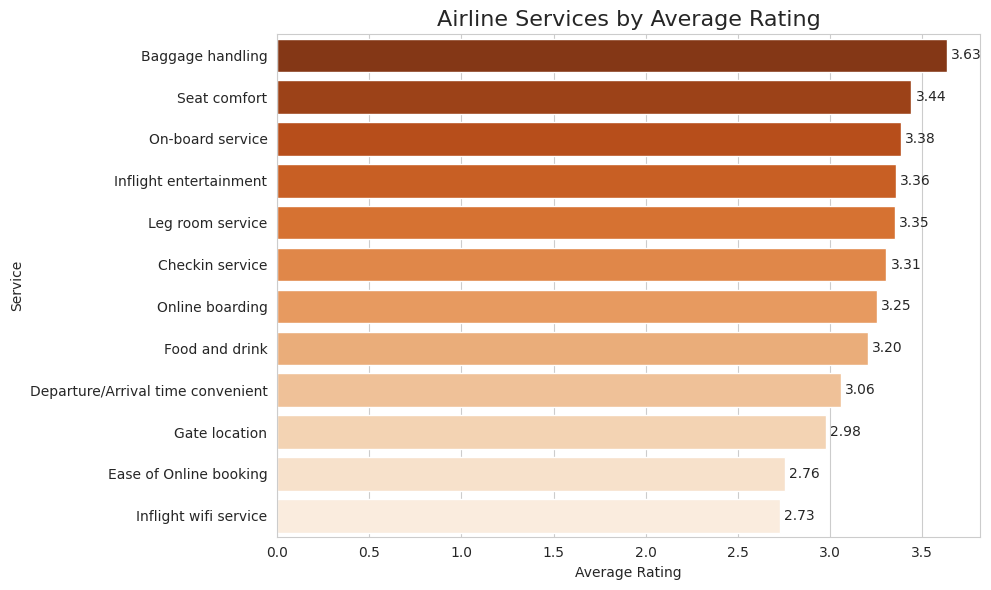

In [ ]:
services = df.iloc[:, 6:18]
avg_services = services.mean()
avg_services = avg_services.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("Oranges", n_colors=len(avg_services))[::-1]
ax = sns.barplot(x=avg_services.values, y=avg_services.index,
                 hue=avg_services.index, palette=colors, legend=False)
plt.title("Airline Services by Average Rating", fontsize=16)
plt.xlabel("Average Rating")
plt.ylabel("Service")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=10)
plt.tight_layout()
plt.show()

**5.l2 Distribusi Variabel Numerik (Boxplot)**

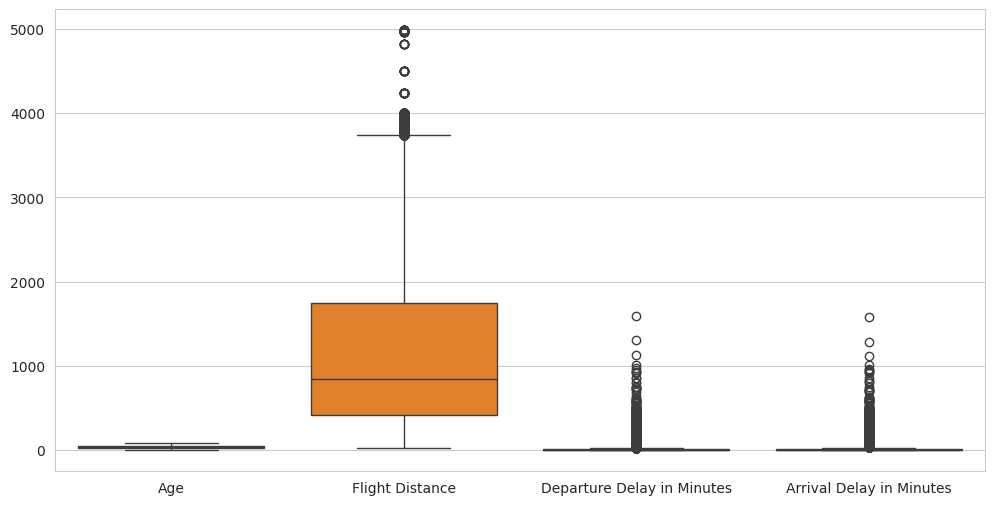

In [ ]:
plt.figure(figsize=(12,6))
num_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
sns.boxplot(data=df[num_cols])
plt.show()

Box plot di atas menunjukkan bahwa **variabel `Age`, `Flight Distance`, `Departure Delay in Minutes`, dan `Arrival Delay in Minutes` memiliki sejumlah pencilan** (*outlier*). Selain itu, keempat variabel tersebut **memiliki rentang nilai yang berbeda**, sehingga disarankan untuk melakukan penskalaan sebelum proses pemodelan untuk menyamakan rentang skala antarvariabel.


**5.13 Korelasi Antar Variabel**

In [ ]:
num_data = df.select_dtypes(include='number')
corr_matrix = num_data.corr()
print(f'Matriks Korelasi Antar Variabel Numerik')
print(corr_matrix)

Matriks Korelasi Antar Variabel Numerik
                                        Age  Flight Distance  \
Age                                1.000000         0.099459   
Flight Distance                    0.099459         1.000000   
Inflight wifi service              0.016116         0.006701   
Departure/Arrival time convenient  0.036960        -0.018914   
Ease of Online booking             0.022565         0.065165   
Gate location                     -0.000398         0.005520   
Food and drink                     0.023194         0.057066   
Online boarding                    0.207572         0.214825   
Seat comfort                       0.159136         0.157662   
Inflight entertainment             0.074947         0.130507   
On-board service                   0.057078         0.111194   
Leg room service                   0.039119         0.134533   
Baggage handling                  -0.047991         0.064855   
Checkin service                    0.033475         0.073608   


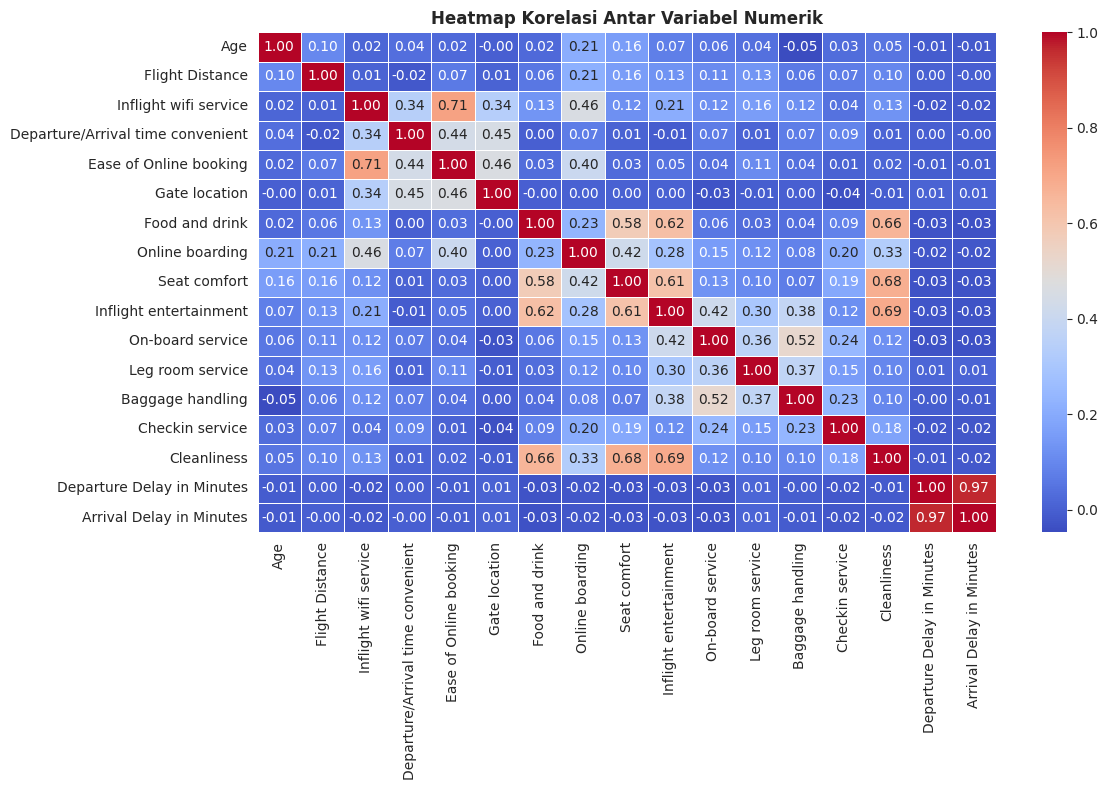

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik', fontweight="bold")
plt.tight_layout()
plt.show()

Matriks korelasi menunjukkan koefisien korelasi antara setiap pasangan variabel numerik. Nilai korelasi berkisar dari -1 hingga 1, di mana:

* 1 menunjukkan korelasi positif sempurna,
* -1 menunjukkan korelasi negatif sempurna, dan
* 0 menunjukkan tidak ada korelasi.

Korelasi berguna untuk memahami sejauh mana variabel saling berhubungan, yang bisa mempengaruhi pemilihan fitur untuk pemodelan atau analisis lebih lanjut. Berikut ini adalah beberapa contoh interpretasi dari hasil heatmap atau matriks korelasi diatas.

1. Korelasi antara usia penumpang (`Age`) dan layanan online boarding(`Online boarding`) sebesar 0.21, menunjukkan bahwa **hubungan kedua variabel relatif lemah**. Dengan kata lain, usia penumpang tidak terlalu berkaitan dengan pemberian rating terhadap layanan online boarding.

2. Korelasi antara kemudahan booking online (`Ease of Online Booking`) dan layanan wifi dalam pesawat (`Inflight wifi service`) sebesar 0.71, menunjukkan bahwa **hubungan kedua variabel cukup kuat**. Artinya, penumpang yang memberikan rating lebih tinggi terhadap kemudahan booking online cenderung memberikan rating yang lebih tinggi juga terhadap layanan Wi-Fi dalam pesawat.

3. Korelasi antara keterlambatan waktu keberangkatan (`Departure Delay in Minutes`) dan keterlambatan waktu kedatangan (`Arrival Delay in Minutes`) sebesar 0.97, menunjukkan bahwa **hubungan kedua variabel sangat kuat**. Maknanya, penumpang yang mengalami keterlambatan waktu keberangkatan akan cenderung mengalami keterlambatan waktu kedatangan juga.



## **4. Data Preprocessing**
---
Sebelum masuk tahap analisis dan membangun model prediksi, akan dipastikan terlebih dahulu data yang digunakan sudah siap untuk dianalisis. Proses dimulai dengan **menangani missing value**, kemudian **mengubah variabel kategorik kedalam bentuk numerik** melalui proses *encoding* agar dapat oleh dibaca algoritma *machine learning*. Langkah berikutnya adalah *features selection* untuk **menentukan variabel target dan prediktor**, dilanjutkan dengan **membagi dataset** menjadi data *training* dan *testing*. Data *training* digunakan untuk membangun model, sedangkan data *testing* digunakan untuk mengevaluasi seberapa baik model yang telah dibangun.

### **4.1 Menyiapkan Data yang Akan Digunakan Untuk Analisis**

In [ ]:
# Data yang Digunakan untuk pemodelan
data = df.drop('age_group', axis = 1)
data

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,5,4,3,4,4,5,25,18.0,False
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,1,5,3,1,1,1,6.0,False
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,5,4,3,4,4,5,0,0.0,True
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,2,5,3,1,2,11,9.0,False
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,5,3,3,4,4,3,3,0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,Male,disloyal Customer,34,Business travel,Business,526,3,3,3,1,...,4,4,3,2,4,4,4,0,0.0,False
129876,Male,Loyal Customer,23,Business travel,Business,646,4,4,4,4,...,4,4,4,5,5,5,4,0,0.0,True
129877,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,1,5,...,2,2,4,3,4,5,2,0,0.0,False
129878,Male,Loyal Customer,14,Business travel,Business,1127,3,3,3,3,...,4,4,3,2,5,4,4,0,0.0,True


### **4.2 Menangani Missing Value**

Setelah dilakukan pengecekan, ditemukan **393 data yang memiliki nilai kosong (missing value)** atau kurang dari 5% dari keseluruhan data. Karena jumlahnya relatif kecil, data yang memiliki nilai kosong tersebut bisa **dihapus** agar dataset lebih bersih dan siap digunakan untuk tahap analisis selanjutnya.


In [ ]:
# Menghapus Missing Value
data = data.dropna()

In [ ]:
print ("Jumlah Missing Value Setelah Penanganan:")
print (data.isnull().sum())

Jumlah Missing Value Setelah Penanganan:
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64


Terlihat bahwa sudah tidak ada lagi nilai kosong pada dataframe.

In [ ]:
print("Data awal     :", df.shape)
print("Data sekarang :", data.shape)

Data awal     : (129880, 23)
Data sekarang : (129487, 22)


### **4.3 Encoding Variabel Kategorik**

**Memasukkan Seluruh Variabel Prediktor**

In [ ]:
data_encode = data.copy()

In [ ]:
# Encoding Variabel Kategorik
# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()

# Kolom-kolom yang perlu di-encode
categorical_columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class",
    "satisfaction"
]

label_encoders = {}

for column in categorical_columns:
  data_encode[column] = label_encoder.fit_transform(data_encode[column])
  label_encoders[column] = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

# Menampilkan hasil encoding
for column, mapping in label_encoders.items():
    print(f"\nHasil Mapping untuk Kolom '{column}':")
    for original_value, encoded_value in mapping.items():
        print(f"'{encoded_value}'= {original_value}")


Hasil Mapping untuk Kolom 'Gender':
'0'= Female
'1'= Male

Hasil Mapping untuk Kolom 'Customer Type':
'0'= Loyal Customer
'1'= disloyal Customer

Hasil Mapping untuk Kolom 'Type of Travel':
'0'= Business travel
'1'= Personal Travel

Hasil Mapping untuk Kolom 'Class':
'0'= Business
'1'= Eco
'2'= Eco Plus

Hasil Mapping untuk Kolom 'satisfaction':
'0'= False
'1'= True


In [ ]:
data_encode.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,5,4,3,4,4,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,1,5,3,1,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,5,4,3,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,2,5,3,1,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,5,3,3,4,4,3,3,0,0.0,1


### **4.4 Features Selection**
Variabel target untuk membuat model prediksi pada proyek ini adalah `satisfaction` yang berisi nilai *False* untuk mewakili penumpang yang tidak puas terhadap layanan maskapai dan *True* untuk mewakili penumpang yang puas terhadap layanan maskapai. Sedangkan 21 variabel lainnya ditetapkan sebagai variabel prediktor.

In [ ]:
# Memisahkan Variabel Prediktor (X) dan Variabel Target (y)
X = data_encode.drop('satisfaction', axis=1)
y = data_encode['satisfaction']
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (129487, 21)
y shape: (129487,)


### **4.5 Pemisahan Data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Jumlah Data Latih:', X_train.shape)
print(f'Jumla Data Uji:', X_test.shape)

Jumlah Data Latih: (103589, 21)
Jumla Data Uji: (25898, 21)


Data dibagi menjadi dua set yaitu data latih (X_train dan y_train) dan data uji (X_test dan y_test). Perbandingan antara data latih dan data uji adalah 80% data latih dan 20% data uji (test_size = 0.2).

In [ ]:
# Features Scaling (membuat skala setiap kolom sama)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **5. Pemodelan Regresi Logistik**

In [ ]:
# Pemodelan Logistic Regression
model = LogisticRegression(max_iter=1000)

# Melatih model menggunakan data training yang sudah di-scaling
model.fit(X_train_scaled, y_train)

# Prediksi pada data testing
y_pred = model.predict(X_test_scaled)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Menampilkan hasil evaluasi
print("Akurasi model:", accuracy)
print("\nLaporan Klasifikasi:\n", classification_rep)

Akurasi model: 0.8740443277473164

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89     14645
           1       0.87      0.84      0.85     11253

    accuracy                           0.87     25898
   macro avg       0.87      0.87      0.87     25898
weighted avg       0.87      0.87      0.87     25898



**1. Akurasi Model**

Akurasi yang dihasilkan oleh model Logistic Regression tersebut adalah sebesar 0.874, yang menunjukkan bahwa model tersebut dapat memprediksi kepuasan penumpang terhadap layanan maskapai dengan **tingkat keakuratan sebesar 87.4%**. Artinya, model dapat memberi **prediksi yang benar pada sekitar 87 dari setiap 100 penumpang** dalam data pengujian.

**2. Laporan Klasifikasi**
* **Precision**: Precision adalah proporsi dari true positive (TP) terhadap semua prediksi positif (TP + false positive (FP)). Untuk kelas 0 (Tidak Puas), precision adalah 0.88, dan untuk kelas 1 (Puas), precision adalah 0.87. Ini menunjukkan seberapa baik model memprediksi tiap kelas.
* **Recall**: Recall adalah proporsi dari true positive (TP) terhadap semua data yang sebenarnya positif (TP + false negative (FN)). Untuk kelas 0 (Tidak Puas), recall adalah 0.90, sementara untuk kelas 1 (Puas), recall adalah 0.84. Ini menggambarkan seberapa baik model dapat mengidentifikasi seluruh kelas tertentu.
* **F1-Score**: F1-score adalah rata-rata harmonik antara precision dan recall. Untuk kelas 0 (Tidak Puas), f1-score adalah 0.89, sedangkan untuk kelas 1 (Puas), f1-score adalah 0.85. F1-score adalah ukuran yang baik untuk menilai keseimbangan antara precision dan recall.
* **Support**: Support adalah jumlah kemunculan masing-masing kelas dalam dataset uji.

**3. Insight**

Hasil laporan klasifikasi menunjukkan bahwa model cenderung **lebih baik dalam mengenali penumpang yang tidak puas (kelas 0)** dibandingkan penumpang yang puas, karena memiliki nilai precision, recall, dan f1-score yang lebih tinggi.

**Kurva ROC**

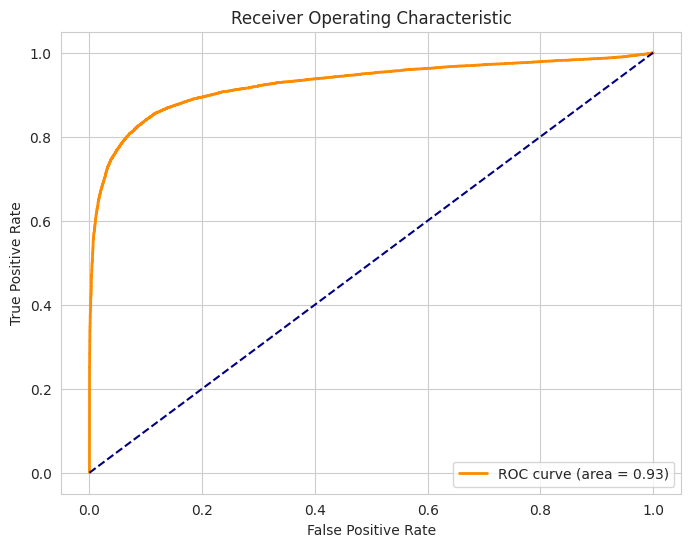

In [ ]:
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# Menghitung nilai AUC-ROC
roc_auc = roc_auc_score(y_test, y_probs)

# Membuat kurva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Menampilkan kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Visualisasi diatas adalah kurva ROC (*Receiver Operating Characteristic*) yang digunakan untuk **melihat seberapa baik model dalam membedakan dua kelompok**, yaitu kelompok penumpang puas dan tidak puas. **Sumbu-X kurva mewakili nilai FPR** (*False Positive Rat*e) yaitu nilai yang menunjukkan proporsi data yang sebenarnya puas, tetapi salah diprediksi sebagai tidak puas. Sedangkan **sumbu-Y mewakili nilai TPR** (*True Positive Rate*) yaitu nilai yang menunjukkan proporsi data yang sebenarnya tidak puas dan berhasil dikenali model sebagai tidak puas.

> Berdasarkan gambar tersebut, nilai AUC (*Area Under of ROC Curve*) sebesar **0.93** menunjukkan bahwa model memiliki kemampuan yang **sangat baik** dalam membedakan kedua kelompok tersebut. Semakin mendekati nilai 1, semakin baik kemampuan model dalam membedakan hasil prediksi.


**Confusion Matrix Heatmap**

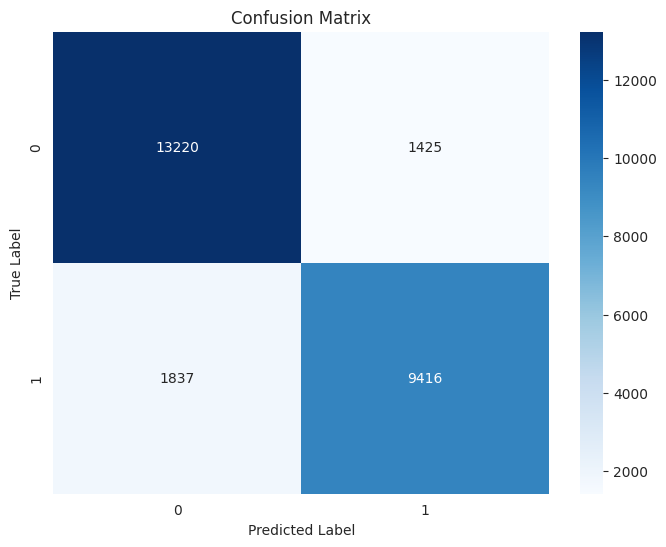

In [ ]:
# Menampilkan heatmap dari matriks konfusi
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.title('Confusion Matrix')
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Gambar diatas menampilkan jumlah prediksi model yang benar dan yang masih salah pada masing-masing kelompok penumpang, yaitu puas dan tidak puas. Nilai pada **diagonal utama menunjukkan nilai prediksi yang benar**, sedangkan bagian lainnya menunjukkan nilai prediksi yang masih salah. Sebagai contoh, pada kelas 0 atau **penumpang yang merasa tidak puas diprediksi benar sejumlah 13220 orang, sedangkan 1425 penumpang masih diprediksi salah**.

**Odds Ratio**

In [ ]:
# Koefisien Model
coefficients = pd.DataFrame({"Variable": X_train.columns, "Coefficient": model.coef_[0]})

# Menghitung Odds Ratio
coefficients["Odds Ratio"] = np.exp(coefficients["Coefficient"])

# Variabel kategorik
categorical_variables = ["Gender", "Type of Travel", "Customer Type", "Class"]

# Mengambil variabel numerik saja
numeric_odds = coefficients[~coefficients["Variable"].isin(categorical_variables)].copy()

# Mengurutkan berdasarkan Odds Ratio
numeric_odds = numeric_odds.sort_values(by="Odds Ratio", ascending=True)

print(numeric_odds)

                             Variable  Coefficient  Odds Ratio
20           Arrival Delay in Minutes    -0.370056    0.690696
8              Ease of Online booking    -0.210612    0.810088
7   Departure/Arrival time convenient    -0.196853    0.821312
2                                 Age    -0.138534    0.870634
10                     Food and drink    -0.053427    0.947975
5                     Flight Distance    -0.013363    0.986726
9                       Gate location     0.031020    1.031507
12                       Seat comfort     0.073768    1.076557
13             Inflight entertainment     0.135292    1.144871
19         Departure Delay in Minutes     0.167265    1.182067
16                   Baggage handling     0.219019    1.244855
18                        Cleanliness     0.272169    1.312809
15                   Leg room service     0.337882    1.401976
14                   On-board service     0.411676    1.509345
17                    Checkin service     0.433134    1

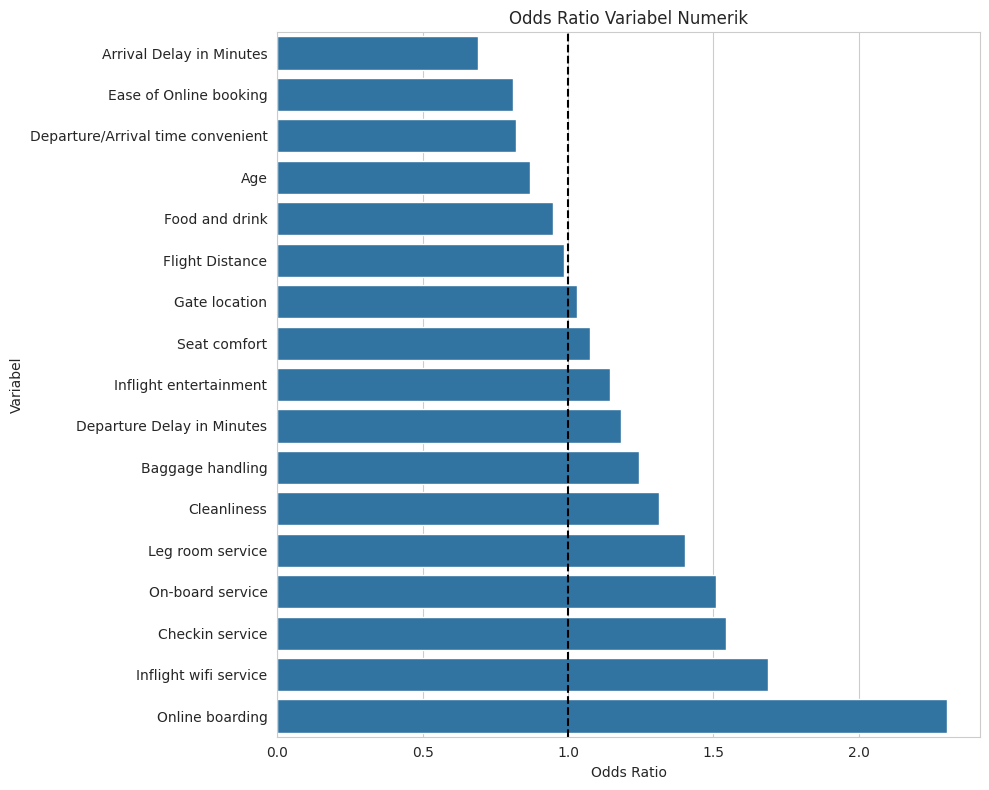

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(data=numeric_odds, x="Odds Ratio", y="Variable")

# Garis OR = 1
plt.axvline(
    x=1,
    color="black",
    linestyle="--")

plt.title("Odds Ratio Variabel Numerik")
plt.xlabel("Odds Ratio")
plt.ylabel("Variabel")

plt.tight_layout()
plt.show()

Odds Ratio (OR) adalah ukuran yang digunakan dalam regresi logistik untuk melihat seberapa kuat suatu variabel berkaitan dengan peluang relatif terjadinya suatu hasil. Dalam proyek ini, hasil yang dianalisis adalah apakah penumpang puas (kelas 1) atau tidak puas (kelas 0). Secara sederhana, OR menjawab pertanyaan "**Ketika suatu variabel meningkat, apakah kecenderungan penumpang untuk puas menjadi lebih besar atau lebih kecil?**"

Secara umum, OR dapat mengalami tiga kondisi berikut.
1. **OR > 1**: Variabel berkaitan dengan peningkatan kepuasan penumpang.
2. **OR < 1**: Variabel berkaitan dengan penurunan kepuasan penumpang.
3. **OR = 1**: Variabel tidak menunjukkan perubahan penilaian kepuasan penumpang.

Berdasarkan hasil Odds Ratio dalam proyek ini, terdapat **6 variabel yang memiliki nilai Odds Ratio lebih kecil dari 1**. Nilai Odds Ratio kurang dari 1 mengindikasikan bahwa variabel tersebut berkaitan dengan penurunan tingkat kepuasan penumpang maskapai. Oleh karena itu, aspek layanan dengan nilai OR kurang dari 1 dapat menjadi perhatian dan bahan evaluasi untuk meningkatkan kualitas layanan dan kepuasan penumpang. Berikut ini variabel yang dimaksudkan.

* `Arrival Delay in Minutes` (OR = 0.690696)
* `Ease of Online Booking` (OR = 0.810088)
* `Departure/Arrival Time Convenient` (OR = 0.821312)
* `Age` (OR = 0.870634)
* `Food and Drink` (OR = 0.947975)
* `Flight Distance` (OR = 0.986726)

## **6. Insight & Recommendations**
---
Berdasarkan hasil analisis data menggunakan *Logistic Regression*, diperoleh beberapa insight yang dapat digunakan untuk memahami kepuasan penumpang terhadap layanan yang diberikan maskapai penerbangan.

### **Insights**

1. Sebanyak 56,6% penumpang berada pada kategori tidak puas, menunjukkan bahwa peningkatan kualitas layanan masih menjadi peluang penting bagi pihak maskapai.

2. Model *Logistic Regression* menghasilkan akurasi sebesar 87,4%. Hal ini menunjukkan bahwa model cukup baik dalam memprediksi kepuasan penumpang berdasarkan faktor layanan dan karakteristiknya.

3. Terdapat 6 variabel yang berkaitan dengan probabilitas penurunan kepuasan penumpang dan dapat menjadi perhatian untuk evaluasi layanan maskapai penerbangan kedepannya.

### **Recommendations**

1. Dalam upaya mengurangi potensi keterlambatan kedatangan, pihak maskapai dapat memperbaiki koordinasi operasional, memberikan informasi dengan jelas, dan memberikan kompensasi yang sesuai kepada penumpang.

  2. Pihak maskapai dapat menyederhanakan proses booking online, melakukan maintenance rutin terhadap website/aplikasi yang digunakan, hingga menyediakan proses pembayaran yang lebih mudah.

  3. Mengevaluasi jadwal penerbangan berdasarkan kebutuhan pelanggan, dan menyediakan lebih banyak pilihan waktu penerbangan.

  4. Melakukan segmentasi penumpang berdasarkan kelompok usia dan menyesuaikan layanan dengan kebutuhan masing-masing kelompok tersebut.

  5. Untuk meningkatkan kualitas makanan & minuman, pihak maskapai dapat melakukan evaluasi rasa, variasi, dan penyajian yang disediakan. Maskapai juga dapat melakukan survei atau mengumpulkan feedback penumpang untuk mengetahui preferensi makanan dan minuman yang lebih sesuai dengan kebutuhan pelanggan.

  6. Menyesuaikan kualitas layanan berdasarkan durasi penerbangan, terutama pada penerbangan jarak jauh, seperti meningkatkan kenyamanan kursi, menyediakan hiburan, dan layanan yang lebih baik selama penerbangan.
